In [173]:
import geopandas as gpd
import pandas as pd
import rasterio
import torch
from osgeo import gdal
import os
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import box
import pystac_client
from pystac_client import Client
from tabulate import tabulate
import odc.stac

#print(rasterio.__gdal_version__)
#print(torch.backends.mps.is_available())

DATA_DIR = "data/"
PRO_DATA_DIR = "data/processed_data/"
print(os.getcwd())


/Users/Kathryn/Documents/Professional Development/CaldorFire


## Module 1

Index(['objectid', 'fire_id', 'fire_name', 'year', 'startmonth', 'startday',
       'fire_type', 'acres', 'irwinid', 'map_id', 'map_prog', 'asmnt_type',
       'ig_date', 'pre_id', 'post_id', 'perim_id', 'dnbr_offst', 'dnbr_stddv',
       'nodata_threshold', 'greenness_threshold', 'low_threshold',
       'moderate_threshold', 'high_threshold', 'comments', 'latitude',
       'longitude', 'st_area(shape)', 'st_perimeter(shape)', 'geometry'],
      dtype='str')
(1, 29)
EPSG:4326
Index(['objectid', 'fire_id', 'fire_name', 'year', 'startmonth', 'startday',
       'fire_type', 'acres', 'irwinid', 'map_id', 'map_prog', 'asmnt_type',
       'ig_date', 'pre_id', 'post_id', 'perim_id', 'dnbr_offst', 'dnbr_stddv',
       'nodata_threshold', 'greenness_threshold', 'low_threshold',
       'moderate_threshold', 'high_threshold', 'comments', 'latitude',
       'longitude', 'st_area(shape)', 'st_perimeter(shape)'],
      dtype='str')
(1956, 28)
1475
<ArrowStringArray>
['Wildfire', 'Prescribed Fire', '

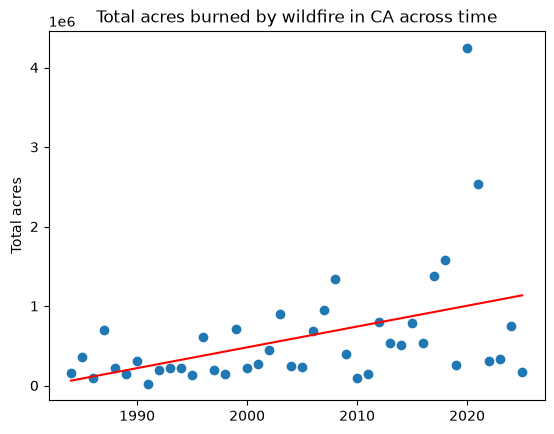

(20, 29)
0.28188188437750505


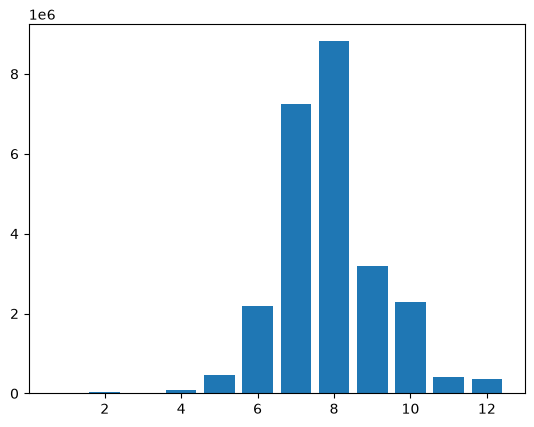

[1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997
 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011
 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
     startmonth  year      acres
102           7  1984    58543.0
103           7  1985   248818.0
29            5  1986    24931.0
146           8  1987   596170.0
187           9  1988   140370.0
107           7  1989    75282.0
149           8  1990   265524.0
190           9  1991     9666.0
151           8  1992   133285.0
232          10  1993   131516.0
153           8  1994   126738.0
154           8  1995    56690.0
155           8  1996   357323.0
156           8  1997   125093.0
157           8  1998    56778.0
158           8  1999   393436.0
117           7  2000   113887.0
160           8  2001   181486.0
119           7  2002   250391.0
242          10  2003   719282.0
243          10  2004    66800.0
82            6  2005    85545.0
204           9  2006   299

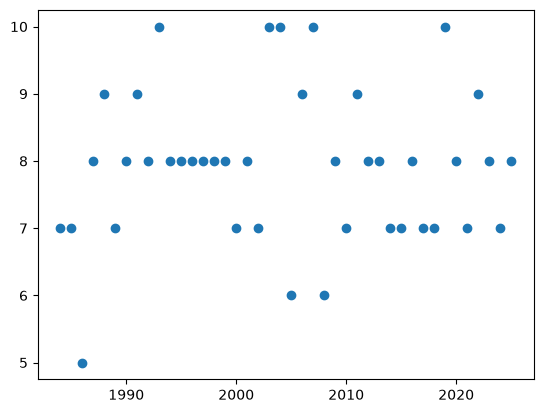

In [99]:
#burned_boundary = gpd.read_file('zip://data/mtbs_perimeter_data.zip')#gpd.read_file('zip:///data/mtbs_perimeter_data.zip')
#print(burned_boundary.head)

caldor_perimeter = gpd.read_file(f'{DATA_DIR}caldor_perimeter.geojson')
mtbs_ca_att = gpd.read_file(f'{DATA_DIR}mtbs_ca_attributes.json')
#print(caldor_perimeter.head())
#print(mtbs_ca_att)
print(caldor_perimeter.columns)
print(caldor_perimeter.shape)
print(caldor_perimeter.crs)
print(mtbs_ca_att.columns)
print(mtbs_ca_att.shape)
#print(caldor_perimeter)
#print(mtbs_ca_att.head())

print(mtbs_ca_att['fire_name'].nunique())

#Edit attribute table
print(mtbs_ca_att['fire_type'].unique())
mtbs_ca_att_edited = mtbs_ca_att.loc[mtbs_ca_att['fire_type'] == "Wildfire",]
print(mtbs_ca_att_edited.shape)
print(mtbs_ca_att_edited['fire_type'].unique())
print(mtbs_ca_att_edited['ig_date'].unique())
mtbs_ca_att_edited['ig_date_dt'] = pd.to_datetime(mtbs_ca_att_edited['ig_date'],format = "%Y%m%d")
print(mtbs_ca_att_edited['ig_date_dt'].unique())

#Total burned acres per year for CA plot
mtbs_ca_att_perYear = mtbs_ca_att_edited.groupby('year')['acres'].sum()
print(mtbs_ca_att_perYear.head())
print(mtbs_ca_att_perYear.index)
slope, intercept = np.polyfit(mtbs_ca_att_perYear.index,mtbs_ca_att_perYear,1)
print(slope)
print(intercept)
trendline_y = slope * mtbs_ca_att_perYear.index + intercept

plt.scatter(mtbs_ca_att_perYear.index,mtbs_ca_att_perYear)
plt.plot(mtbs_ca_att_perYear.index, trendline_y,color="red",label="Trend Line")
plt.title("Total acres burned by wildfire in CA across time")
plt.ylabel("Total acres")
plt.show()
#There is a trend. Total burned acres is increasing over time

#Filter to the 20 largest CA wildfires by acreage. What fraction of all CA burned area since 1984 do they account for
sorted_fires = mtbs_ca_att_edited.sort_values(by='acres',ascending=False)
largest_fires = sorted_fires.iloc[0:20,]
print(largest_fires.shape)
print(largest_fires['acres'].sum()/mtbs_ca_att_edited['acres'].sum()) #20 largest fires account for 28% of all CA burned area since 1984 

#How concentrated is fire season and has the centroid shifted?
mtbs_ca_att_perMonth = mtbs_ca_att_edited.groupby("startmonth")['acres'].sum()
plt.bar(mtbs_ca_att_perMonth.index,mtbs_ca_att_perMonth)
plt.show()
mtbs_ca_att_perMonthYear = mtbs_ca_att_edited.groupby(['startmonth','year'],as_index=False)['acres'].sum()
peak = mtbs_ca_att_perMonthYear.loc[mtbs_ca_att_perMonthYear.groupby('year')['acres'].idxmax()].sort_values('year')
print(peak['year'].unique())
print(peak)

plt.scatter(peak['year'],peak['startmonth'])
plt.show()
#i dont see a shift in this specific centroid



In [224]:
#filter to caldor
caldor_att = mtbs_ca_att_edited.loc[mtbs_ca_att_edited['fire_name']=="CALDOR",]
print(caldor_att)

#Reproject to UTM
utm_crs = caldor_perimeter.estimate_utm_crs()
caldor_perimeter_reprojected = caldor_perimeter.to_crs(utm_crs)
print(utm_crs)

#Compute area and compare
caldor_area = caldor_perimeter_reprojected.area / 4046.85642 #Convert from square meters to acres
print(caldor_area)
print(caldor_att['acres'])

#Save the extent
caldor_perimeter_reprojected_buffered = caldor_perimeter_reprojected.buffer(2000)
caldor_perimeter_bounds = caldor_perimeter_reprojected_buffered.to_crs('EPSG:4326').bounds

geometry = caldor_perimeter_bounds.apply(lambda row: box(row['minx'], row['miny'], row['maxx'], row['maxy']), axis=1)
caldor_perimeter_bounds = gpd.GeoDataFrame(caldor_perimeter_bounds, geometry=geometry, crs="EPSG:4326")
print(caldor_perimeter_bounds)
#print(geometry)

caldor_perimeter_reprojected.to_file(f'{PRO_DATA_DIR}caldor_perimeter.gpkg', driver="GPKG")
caldor_perimeter_bounds.to_file(f'{PRO_DATA_DIR}caldor_bounds.geojson', driver="GeoJSON")

#Save fire ignition date
caldor_date = caldor_att['ig_date_dt']
caldor_date = pd.Timestamp(pd.Series(caldor_date).iloc[0]).date()
print(caldor_date)

      objectid                fire_id fire_name  year  startmonth  startday  \
1856    670397  CA3858612053820210815    CALDOR  2021           8        15   

     fire_type     acres                               irwinid    map_id  ...  \
1856  Wildfire  226739.0  E6C053C8-A346-43FB-9C29-632BC7536717  10024007  ...   

     greenness_threshold low_threshold  moderate_threshold high_threshold  \
1856                -150           116                 312            553   

     comments   latitude   longitude  st_area(shape)  st_perimeter(shape)  \
1856      NaN  38.705891 -120.312748        0.094974             2.870174   

      ig_date_dt  
1856  2021-08-15  

[1 rows x 29 columns]
EPSG:32610
0    226738.855941
dtype: float64
1856    226739.0
Name: acres, dtype: float64
         minx       miny        maxx       maxy  \
0 -120.678853  38.539017 -119.900763  38.908666   

                                            geometry  
0  POLYGON ((-119.90076 38.53902, -119.90076 38.9...  
2021

## Module 2


In [253]:
sentinel_url = "https://earth-search.aws.element84.com/v1"

client = Client.open(sentinel_url)

caldor_bbox = [caldor_perimeter_bounds['minx'][0],
              caldor_perimeter_bounds['miny'][0],
              caldor_perimeter_bounds['maxx'][0],
              caldor_perimeter_bounds['maxy'][0]]
#print(caldor_bbox)
datetime = "2021-07-01/2021-08-10" #Range of dates before the fire
datetime = "2022-07-01/2022-08-31" #Range of dates after the fire 
#caldor_date

def search_and_pull_sentinel_data(datetime,expected_tiles = 6):
    search = client.search(
        collections=["sentinel-2-l2a"],
        bbox=caldor_bbox,
        datetime=datetime,
        query={"eo:cloud_cover": {"lt": 10}}
    )
    search_prop = []
    items = list(search.items())
    for item in items:
        new_row = {
            "id": item.id,
            "datetime": item.datetime,
            "cloud_cover": item.properties["eo:cloud_cover"],
            "grid_code": item.properties["grid:code"],
            "processing_baseline": item.properties["s2:processing_baseline"],
            "boa_offset_applied": item.properties["earthsearch:boa_offset_applied"]         
        }
        search_prop.append(new_row)

    search_prop = pd.DataFrame(search_prop)
    search_prop["date"] = search_prop["datetime"].dt.date

    search_prop = search_prop.loc[:, ~search_prop.columns.duplicated()]

    idx = search_prop.groupby(['grid_code','date'])['processing_baseline'].idxmax()
    items_dedup = [items[i] for i in idx]
    items_dedup = [i for i in items_dedup if i.properties["earthsearch:boa_offset_applied"]]

    assert len({i.properties["earthsearch:boa_offset_applied"] for i in items_dedup}) == 1

    #Identify which date is best to use based on most cloud-free coverage
    tile_counts = pd.Series([i.datetime.date() for i in items_dedup]).value_counts().sort_values(ascending=False)
    tile_counts = tile_counts.loc[tile_counts == expected_tiles]
    #return search_prop

    search_prop_potential = search_prop.loc[search_prop['date'].isin(list(tile_counts.index))]

    cloud_cover_max = search_prop_potential.groupby('date',as_index=False)['cloud_cover'].max()
    cloud_cover_best_date = cloud_cover_max.loc[cloud_cover_max['cloud_cover'].idxmin()]['date']

    #Filter items to just the best date
    items_dedup = [i for i in items_dedup if i.datetime.date() == cloud_cover_best_date]

    #Load into xarray
    ds = odc.stac.load(
        items_dedup,
        bands=["blue","green","red","nir","nir08","swir16","swir22","scl"], 
        chunks={"x": 2048, "y": 2048},   # Optional: Enable lazy loading via Dask
        resolution=20,
        bbox = caldor_bbox,
        crs = utm_crs
    )
    return(ds)

ds_before = search_and_pull_sentinel_data(datetime = "2021-07-01/2021-08-10")
ds_after = search_and_pull_sentinel_data(datetime = "2022-07-01/2022-08-31")
print(ds_after)

<xarray.Dataset> Size: 667MB
Dimensions:      (y: 2153, x: 3444, time: 6)
Coordinates:
  * y            (y) float64 17kB 4.311e+06 4.311e+06 ... 4.268e+06 4.268e+06
  * x            (x) float64 28kB 7.013e+05 7.013e+05 ... 7.701e+05 7.701e+05
  * time         (time) datetime64[us] 48B 2022-07-08T19:03:37.588000 ... 202...
    spatial_ref  int32 4B 32610
Data variables:
    blue         (time, y, x) uint16 89MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    green        (time, y, x) uint16 89MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    red          (time, y, x) uint16 89MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir          (time, y, x) uint16 89MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir08        (time, y, x) uint16 89MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    swir16       (time, y, x) uint16 89MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    swir22       (time, y, x) uint16 89MB dask